# Winds (Part 2) - Bias and Cross-Section

## Wind Model Inset

### Global Importation

In [1]:
# Shape modules 
from collections import defaultdict

# Computational modules 
%matplotlib inline
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed


## Ensemble Data

### Load Interpolated Data ($u$ Component)

In [2]:
model_short = 'UKESM'
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Winds/"
path_figure = f'/home/users/alvin_ch/figures/Multi-model/'
filename = "ua_interpolated.nc"
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

interpolated_model_u_files = {}

for ens in ensemble_members:
    interpolated_model_u_files[ens] = xr.open_mfdataset(f'{path_files}{ens}_{filename}', combine='by_coords', use_cftime=True)

### Filter Ensemble Data

In [18]:
# Now we are interested in the same period as what we have in the observations.
# Period 1979-2014.

time_filtered_ens_u = {}

for ens in ensemble_members:
    time_filtered_ens_u[ens] = interpolated_model_u_files[ens].sel(time=slice("1979-01-01", "2015-01-01"))
    
    # Check time slicing.
    if ens == 'r1i1p1f1':
        print("Start:", time_filtered_ens_u[ens].time.min().values)
        print("End:", time_filtered_ens_u[ens].time.max().values)
        print("Number of time steps:", time_filtered_ens_u[ens].time.size)

Start: 1979-01-16 00:00:00
End: 2014-12-16 00:00:00
Number of time steps: 432


### Implementation 1a (Seasonal Average)

In [19]:
def compute_seasonal_average_customed_MJJAS(data):

    # Keep only May–September
    data_mjjas = data.sel(time=data['time.month'].isin([5, 6, 7, 8, 9]))

    # Average over time
    seasonal_avg = data_mjjas.mean(dim='time')
    return seasonal_avg

def seasonal_average_over_years_customed_MJJAS(data) :
    year_list_tmp = data.groupby('time.year').mean()
    year_list = year_list_tmp['year'].values[:-1]
    avg_list = []

    for y in year_list:
        data_1yr = data.sel(time=slice(str(y), str(y)))
        avg = compute_seasonal_average_customed_MJJAS(data_1yr)
        avg_list.append(avg)

    # Concatenate in new Xarray
    # Create labeled coordinate array for the new dimension
    year_coord = xr.DataArray(year_list, dims='year')

    # Concatenate
    combined = xr.concat(avg_list, dim=year_coord)
    return combined

In [20]:
seas = 'MJJAS'
seas_avg_model_u = {}
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

for expe in ensemble_members:
    # u-component
    data_u = time_filtered_ens_u[expe]
    seas_avg_model_u[expe] = seasonal_average_over_years_customed_MJJAS(data_u)

In [23]:
seas_avg_model_u[ensemble_members[0]]

<xarray.Dataset> Size: 2MB
Dimensions:         (year: 35, longitude: 144, bnds: 2, latitude: 72)
Coordinates:
  * longitude       (longitude) float32 576B 1.25 3.75 6.25 ... 356.2 358.8
  * latitude        (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * year            (year) int64 280B 1979 1980 1981 1982 ... 2011 2012 2013
Dimensions without coordinates: bnds
Data variables:
    longitude_bnds  (year, longitude, bnds) float32 40kB dask.array<chunksize=(1, 144, 2), meta=np.ndarray>
    latitude_bnds   (year, latitude, bnds) float32 20kB dask.array<chunksize=(1, 72, 2), meta=np.ndarray>
    ua              (year, latitude, longitude) float32 1MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>

### Compute Zonal Mean

In [31]:
model_u_zonal_mean = {}

lonmin, lonmax = -20, 20
latmin, latmax = -5, 20

for ens in ensemble_members:
    model_u_zonal_mean[ens] = seas_avg_model_u[ens].sel(longitude=slice(lonmin, lonmax)).mean('longitude')

In [33]:
model_u_zonal_mean[ensemble_members[0]]['ua'].values[:1]

array([[        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan, -3.5927186 ,  1.7921244 ,
         5.9979496 ,  8.461426  , 10.046096  , 11.695805  , 13.38205   ,
        14.15742   , 13.708378  , 12.682874  , 11.015755  ,  8.827026  ,
         6.1298037 ,  3.6755533 ,  1.6895468 ,  0.14820555, -1.0116943 ,
        -1.7295065 , -1.9268777 , -2.440397  , -2.924591  , -2.5965087 ,
        -1.4289331 , -2.4139466 , -2.9748778 , -2.3929667 , -1.8271179 ,
        -0.9172181 ,  0.44032592,  1.0646605 ,  0.9983765 ,  1.4777466 ,
         1.0678385 , -1.6744385 , -3.814508  , -4.6360025 , -5.521702  ,
        -5.4126225 , -4.560667  , -2.5809264 , -0.39637047,  0.75719   ,
         1.8207723 ,  1.8854737 ,  1.1333802 ,  0.6830852 ,  1.2038534 ,
         3.1860209 ,  4.3598223 ,  5.110712  ,  4.8571453 ,  3.3617127 ,
         2.6142232 ,  3.7254882 ,  3.1397357 ,  2.5907571 ,  1.656079  ,
         1.3118265 ,  1.4118936 ,  1.2774028 ,  1.0

### Implementation 1b (Plot Wind Cross-Section)

In [ ]:
def u_wind_cross_section(u_wind, cbar_label, palette, latmin, latmax, pmin, pmax,
                         title, Save, filename, p_values):

    fig = plt.figure(figsize=(10, 10), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1)

    step = 2

    # Extract u-component and thin the data
    u_values = u_wind.values[::step, ::step]

    # Latitude and pressure coordinates
    lat = u_wind['latitude'].values
    pressure = u_wind['plev'].values

    # Create latitude-pressure grid
    lat2d, pressure2d = np.meshgrid(lat, pressure)

    x = lat2d[::step, ::step]
    y = pressure2d[::step, ::step]

    # Only plot the u-component:
    # positive u -> right/eastward
    # negative u -> left/westward
    v_zero = np.zeros_like(u_values)

    arrows = ax.quiver(
        x, y,
        u_values, v_zero,
        scale=45,
        pivot='middle'
    )

    # Reference arrow
    ax.quiverkey(
        arrows,
        X=0.895,
        Y=1.03,
        U=1,
        label='1 m/s',
        labelpos='E',
        coordinates='axes'
    )

    ### AXES ###

    # Pressure decreases upwards
    ax.set_yscale('log')
    ax.invert_yaxis()

    ax.set_xlim(latmin, latmax)
    ax.set_ylim(pmax, pmin)

    ax.set_xlabel('Latitude (°)', fontsize=15)
    ax.set_ylabel('Pressure Level (hPa)', fontsize=15)

    ax.tick_params(axis='both', labelsize=12)

    ax.set_title(title, fontsize=15)

    ### GRID ###
    ax.grid(True, linestyle='--', alpha=0.5)

    ### SAVE ###
    if Save:
        plt.savefig(
            filename,
            bbox_inches='tight',
            pad_inches=0.1,
            dpi=450
        )

    plt.show()

## Observation Data

### Load Raw Data ($u$ Component)

In [44]:
years_list = []
raw_all_u_data = {}

data_dir = '/home/users/pmonerie001/tempo/ERA5'

# There are 83 years in the ERA5 observations set.
for i in range(36):
    years_list.append(str(1979+i))

for yr in years_list:
    tmp_path = f'{data_dir}/U_{yr}.nc'
    raw_all_u_data[yr] = xr.open_mfdataset(f'{tmp_path}', combine='by_coords', use_cftime=True)

In [49]:
raw_all_u_data['2014']

<xarray.Dataset> Size: 29MB
Dimensions:         (valid_time: 12, pressure_level: 19, latitude: 261,
                     longitude: 121)
Coordinates:
    number          int64 8B ...
  * valid_time      (valid_time) object 96B 2014-01-01 00:00:00 ... 2014-12-0...
  * pressure_level  (pressure_level) float64 152B 1e+03 925.0 850.0 ... 5.0 1.0
  * latitude        (latitude) float64 2kB 45.0 44.75 44.5 ... -19.75 -20.0
  * longitude       (longitude) float64 968B -15.0 -14.75 -14.5 ... 14.75 15.0
    expver          (valid_time) <U4 192B dask.array<chunksize=(12,), meta=np.ndarray>
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 29MB dask.array<chunksize=(6, 10, 131, 61), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 Thu Jul 30 22:21:26 2026: ncatted -O -a units,la...
    NCO:                     netCDF Operators version 5.3.3 (Homepage = http:...

### Merge Data

In [46]:
def all_years_obs_files_merge(files_dict, file_list):

    assert len(files_dict) == len(file_list)

    ds = []
    
    for i in range(len(file_list)):
        ds.append(files_dict[file_list[i]])

    merged = xr.concat(ds, dim="valid_time")
    merged = merged.compute()
    
    merged.to_netcdf(f"{path_files}u_obs_all_years_time_merged.nc")
    merged.close()

In [47]:
# Merge files.
# all_years_obs_files_merge(raw_all_u_data, years_list)

### Load Interpolated Data

In [48]:
all_u_obs_interpolated = xr.open_mfdataset(f"{path_files}u_obs_all_years_interpolated.nc", combine='by_coords', use_cftime=True)
all_u_obs_interpolated

array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        ...,

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan

### Implementation 2a (Seasonal Average Over Time)

In [10]:
def seasonal_average_over_years_MJJAS_obs(data):

    # Select May-September
    data_mjjas = data.sel(valid_time=data.valid_time.dt.month.isin([5, 6, 7, 8, 9]))

    # Create annual MJJAS averages
    seasonal_avg = data_mjjas.groupby('valid_time.year').mean('valid_time')
    return seasonal_avg

### Standardise Coordinates

In [8]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

### Compute Seasonal Mean

In [13]:
seas = 'MJJAS'
seas_avg_obs = {}
obs_list = ['obs']

for expe in obs_list:
    obs_data = all_u_obs_interpolated
    seas_avg_obs['obs'] = seasonal_average_over_years_MJJAS_obs(obs_data)

In [36]:
all_u_obs_interpolated['u'].values[:1]

array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        ...,

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan

### Compute Zonal Mean Over Time

In [34]:
lonmin, lonmax = -20, 20
latmin, latmax = -5, 20

all_u_obs_zonal_mean = seas_avg_obs['obs'].sel(longitude=slice(lonmin, lonmax)).mean('longitude')

In [35]:
all_u_obs_zonal_mean['u'].values[:1]

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 19, 72), dtype=float32)

### Implementation 2a (Observations Plot)

100%|█████████████████████████████| 2/2 [00:00<00:00,  8.38it/s]


In [7]:
# Ensemble r2i1p1f1
config_2 = 'r2i1p1f1'
sub3 = 'v20241203'
file_list_6 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_2}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_2}_gn_195001-201412']

files_ens_6 = {}
for expe in tqdm(file_list_6):
    path_tmp = (f"{path}{esm_var}/{config_2}/{Table_ID}/{var}/{sub1}/{sub3}/{expe}{filetype}")
    files_ens_6[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 13.14it/s]


In [8]:
# Ensemble r3i1p1f1
config_3 = 'r3i1p1f1'
sub4 = 'v20241211'
file_list_7 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_3}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_3}_gn_195001-201412']

files_ens_7 = {}
for expe in tqdm(file_list_7):
    path_tmp = (f"{path}{esm_var}/{config_3}/{Table_ID}/{var}/{sub1}/{sub4}/{expe}{filetype}")
    files_ens_7[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 13.66it/s]


In [9]:
config_4 = 'r4i1p1f1'
sub5 = 'v20260623'
file_list_8 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_4}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_4}_gn_195001-201412']

files_ens_8 = {}
for expe in tqdm(file_list_8):
    path_tmp = (f"{path}{esm_var}/{config_4}/{Table_ID}/{var}/{sub1}/{sub5}/{expe}{filetype}")
    files_ens_8[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 17.81it/s]


### Merge Pre-Interpolated Data

In [10]:
# Merge files of the same ensemble together.
# Implementation
def two_files_merge_ua(files_dict, file_list, ensemble_member):
    ds1 = files_dict[file_list[0]]
    ds2 = files_dict[file_list[1]]

    # Concatenate along time
    merged = xr.concat([ds1, ds2], dim="time")

    # Ensure data is computed before writing
    merged = merged.load()

    # Write actual data to disk
    merged.to_netcdf(f"{path_files}/{ensemble_member}_ua_time_merged.nc", mode='w')


def two_files_merge_va(files_dict, file_list, ensemble_member):
    ds1 = files_dict[file_list[0]]
    ds2 = files_dict[file_list[1]]

    # Concatenate along time
    merged = xr.concat([ds1, ds2], dim="time")

    # Ensure data is computed before writing
    merged = merged.load()

    # Write actual data to disk
    merged.to_netcdf(f"{path_files}/{ensemble_member}_va_time_merged.nc", mode='w')

In [11]:
# u-components
# r1i1p1f1
# two_files_merge_ua(files_ens_1, file_list_1, 'r1i1p1f1')

# r2i1p1f1
# two_files_merge_ua(files_ens_2, file_list_2, 'r2i1p1f1')

# r3i1p1f1
# two_files_merge_ua(files_ens_3, file_list_3, 'r3i1p1f1')

# r4i1p1f1
# two_files_merge_ua(files_ens_4, file_list_4, 'r4i1p1f1')

In [12]:
# v-components
# r1i1p1f1
# two_files_merge_va(files_ens_5, file_list_5, 'r1i1p1f1')

# r2i1p1f1
# two_files_merge_va(files_ens_6, file_list_6, 'r2i1p1f1')

# r3i1p1f1
# two_files_merge_va(files_ens_7, file_list_7, 'r3i1p1f1')

# r4i1p1f1
# two_files_merge_va(files_ens_8, file_list_8, 'r4i1p1f1')

### Slicing Pressure Level

In [13]:
files_ens_8[expe]

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 780, bnds: 2, plev: 19, lat: 145, lon: 192)
Coordinates:
  * time       (time) object 6kB 1950-01-16 00:00:00 ... 2014-12-16 00:00:00
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat        (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon        (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 12kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(145, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    va         (time, plev, lat, lon) float32 2GB dask.array<chunksize=(1, 19, 145, 192), meta=np.ndarray>
Attributes: (12/39)
    Conventions:           CF-1.7 CMIP-6.2
    activity_id:           TerraFIRMA
    branch_method:         no parent
    creation_date:         2026-06-18T17:05:50Z
    cv_version:            GCModelDev v0.0.23
    data_specs_version:    GCModelDev v0.0.23
    ...                    ...
    tracking_id:           GCMODELDEV/69170d3b-edc9-4e42-85b7-301b95e07f91
    variable_id:           va
    variable_name:         va
    variant_label:         r4i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.8.0

In [14]:
def select_plevel(ds_path, ensemble, vector):
    # Load dataset explicitly
    ds = xr.open_dataset(ds_path)

    # Select 850 hPa (Pa units)
    pl850 = ds.sel(plev=85000, method='nearest')

    # Compute before writing to avoid lazy write freeze.
    pl850 = pl850.load()

    # Save actual data
    # pl850.to_netcdf(f"{path_files}{ensemble}_{vector}_plev_850.nc", mode='w')

In [15]:
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']
vectors = ['ua', 'va']

for ens in ensemble_members:
    for vector in vectors:
        temp_path = f"{path_files}{ens}_{vector}_time_merged.nc"
        select_plevel(temp_path, ens, vector)

In [16]:
# Check file quality.
test = xr.open_dataset(f'{path_files}r1i1p1f1_ua_plev_850.nc')
check = test['ua']
check.values[:1]

array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.4223633, -1.3276367, -1.2363281, ..., -1.7133789,
         -1.6162109, -1.519043 ],
        [-2.2788086, -2.1450195, -2.010254 , ..., -2.6706543,
         -2.541748 , -2.4111328],
        [-2.9038086, -2.7404785, -2.574463 , ..., -3.3742676,
         -3.2209473, -3.0639648]]], shape=(1, 145, 192), dtype=float32)

### Load Interpolated Data ($u$ Component)

### Load Interpolated Data ($v$ Component)

In [18]:
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Winds/"
filename = "va_interpolated.nc"
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

interpolated_model_v_files = {}

for ens in ensemble_members:
    interpolated_model_v_files[ens] = xr.open_mfdataset(f'{path_files}{ens}_{filename}', combine='by_coords', use_cftime=True)

### Filter Ensemble Data (Climatology)

In [19]:
# Now we are interested in the same period as what we have in the observations.
# Period 1979-2014.
# Slice at pressure level 850 hPa.

time_filtered_ens_u = {}
time_filtered_ens_v = {}

for ens in ensemble_members:
    time_filtered_ens_u[ens] = interpolated_model_u_files[ens].sel(time=slice("1979-01-01", "2015-01-01"))
    time_filtered_ens_v[ens] = interpolated_model_v_files[ens].sel(time=slice("1979-01-01", "2015-01-01"))
    
    # Check time slicing.
    if ens == 'r1i1p1f1':
        print("Start:", time_filtered_ens_u[ens].time.min().values)
        print("End:", time_filtered_ens_u[ens].time.max().values)
        print("Number of time steps:", time_filtered_ens_u[ens].time.size)

Start: 1979-01-16 00:00:00
End: 2014-12-16 00:00:00
Number of time steps: 432


### Implementation 1a (Seasonal Mean, Over Time)

In [20]:
def compute_seasonal_average_customed_MJJAS(data):

    # Keep only May–September
    data_mjjas = data.sel(time=data['time.month'].isin([5, 6, 7, 8, 9]))

    # Average over time
    seasonal_avg = data_mjjas.mean(dim='time')
    return seasonal_avg

def seasonal_average_over_years_customed_MJJAS(data) :
    year_list_tmp = data.groupby('time.year').mean()
    year_list = year_list_tmp['year'].values[:-1]
    avg_list = []

    for y in year_list:
        data_1yr = data.sel(time=slice(str(y), str(y)))
        avg = compute_seasonal_average_customed_MJJAS(data_1yr)
        avg_list.append(avg)

    # Concatenate in new Xarray
    # Create labeled coordinate array for the new dimension
    year_coord = xr.DataArray(year_list, dims='year')

    # Concatenate
    combined = xr.concat(avg_list, dim=year_coord)
    return combined

In [21]:
seas = 'MJJAS'
seas_avg_model_u = {}
seas_avg_model_v = {}
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

for expe in ensemble_members:
    # u-component
    data_u = time_filtered_ens_u[expe]
    seas_avg_model_u[expe] = seasonal_average_over_years_customed_MJJAS(data_u)

    # v-component
    data_v = time_filtered_ens_v[expe]
    seas_avg_model_v[expe] = seasonal_average_over_years_customed_MJJAS(data_v)

In [22]:
seas_avg_model_v[ensemble_members[0]]['va'].values[:1]

array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.24165034, -0.26274413, -0.2848633 , ..., -0.19295251,
         -0.19785157, -0.22000328],
        [ 0.5438802 ,  0.5228516 ,  0.49285483, ...,  0.5401042 ,
          0.55371094,  0.5548177 ],
        [ 0.62947595,  0.66621095,  0.6951009 , ...,  0.5019368 ,
          0.5438477 ,  0.587679  ]]], shape=(1, 72, 144), dtype=float32)

### Compute Ensemble Mean

In [23]:
def compute_ensemble_mean(ensemble_list, data_dict, variable):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [24]:
climatology_ens_mean_u = compute_ensemble_mean(ensemble_members, seas_avg_model_u, 'ua')
climatology_ens_mean_u

<xarray.DataArray 'ua' (year: 35, latitude: 72, longitude: 144)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(35, 72, 144), dtype=float32, chunksize=(1, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * year       (year) int64 280B 1979 1980 1981 1982 ... 2010 2011 2012 2013

In [25]:
climatology_ens_mean_v = compute_ensemble_mean(ensemble_members, seas_avg_model_v, 'va')
climatology_ens_mean_v

<xarray.DataArray 'va' (year: 35, latitude: 72, longitude: 144)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(35, 72, 144), dtype=float32, chunksize=(1, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * year       (year) int64 280B 1979 1980 1981 1982 ... 2010 2011 2012 2013

### Compute Resultant Wind Vectors

In [26]:
# Magnitude
resultant_speed = np.sqrt(climatology_ens_mean_u**2 + climatology_ens_mean_v**2)

In [27]:
# Mathematical direction.
# Used for quiver in plot.
direction = np.arctan2(climatology_ens_mean_v, climatology_ens_mean_u)

In [28]:
# Inset axes for arrow (quiver) plot.
lats = climatology_ens_mean_u['latitude'].values
lons = climatology_ens_mean_u['longitude'].values

lon2d, lat2d = np.meshgrid(lons, lats)

## Surface Pressure Model Inset

### Load Raw Data (Ensemble Pre-Interpolation)

In [29]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'
path_figure = f"/home/users/alvin_ch/figures/Multi-model/{model_short}/Winds/"
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Winds/"

path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-hist'
config_1 = 'r1i1p1f1'
var = 'psl'
sub1 = 'gn'
sub2 = 'v20240619'
file_list_9 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_1}_gn_185001-194912',
             f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_1}_gn_195001-201412']

files_ens_9 = {}
filetype = '.nc'
for expe in tqdm(file_list_9):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{sub1}/{sub2}/{expe}{filetype}")
    files_ens_9[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 12.59it/s]


In [30]:
# Ensemble r2i1p1f1
config_2 = 'r2i1p1f1'
sub3 = 'v20241203'
file_list_10 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_2}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_2}_gn_195001-201412']

files_ens_10 = {}
for expe in tqdm(file_list_10):
    path_tmp = (f"{path}{esm_var}/{config_2}/{Table_ID}/{var}/{sub1}/{sub3}/{expe}{filetype}")
    files_ens_10[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 14.86it/s]


In [31]:
# Ensemble r3i1p1f1
config_3 = 'r3i1p1f1'
sub4 = 'v20241211'
file_list_11 = [f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_3}_gn_185001-194912',
               f'{var}_Amon_UKESM1-2-LL_esm-hist_{config_3}_gn_195001-201412']

files_ens_11 = {}
for expe in tqdm(file_list_11):
    path_tmp = (f"{path}{esm_var}/{config_3}/{Table_ID}/{var}/{sub1}/{sub4}/{expe}{filetype}")
    files_ens_11[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 14.39it/s]


### Merge Pre-Interpolated Data

In [32]:
def two_files_merge(files_dict, file_list, ensemble_member):
    ds1 = files_dict[file_list[0]]
    ds2 = files_dict[file_list[1]]

    # Concatenate along time
    merged = xr.concat([ds1, ds2], dim="time")

    # Ensure data is computed before writing
    merged = merged.load()

    # Write actual data to disk
    merged.to_netcdf(f"{path_files}/{ensemble_member}_psl_time_merged.nc", mode='w')

In [33]:
# r1i1p1f1
# two_files_merge(files_ens_9, file_list_9, 'r1i1p1f1')

# r2i1p1f1
# two_files_merge(files_ens_10, file_list_10, 'r2i1p1f1')

# r3i1p1f1
# two_files_merge(files_ens_11, file_list_11, 'r3i1p1f1')

### Load Interpolated Data

In [34]:
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Winds/"
filename = "psl_interpolated.nc"
ensemble_members_psl = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1']

interpolated_model_psl_files = {}

for ens in ensemble_members_psl:
    interpolated_model_psl_files[ens] = xr.open_mfdataset(f'{path_files}{ens}_{filename}', combine='by_coords', use_cftime=True)

### Filter Ensemble Data (Climatology)

In [35]:
# Now we are interested in the same period as what we have in the observations.
# Period 1979-2014.
# Note that psl in this file is expressed in terms of Pascals (Pa).

time_filtered_ens_psl = {}

for ens in ensemble_members_psl:
    time_filtered_ens_psl[ens] = interpolated_model_psl_files[ens].sel(time=slice("1979-01-01", "2015-01-01"))

    # Check time slicing.
    if ens == 'r1i1p1f1':
        print("Start:", time_filtered_ens_psl[ens].time.min().values)
        print("End:", time_filtered_ens_psl[ens].time.max().values)
        print("Number of time steps:", time_filtered_ens_psl[ens].time.size)

Start: 1979-01-16 00:00:00
End: 2014-12-16 00:00:00
Number of time steps: 432


### Compute Seasonal Mean, Over Time

In [36]:
seas = 'MJJAS'
seas_avg_model_psl = {}
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1']

for expe in ensemble_members_psl:
    data_psl = time_filtered_ens_psl[expe]
    seas_avg_model_psl[expe] = seasonal_average_over_years_customed_MJJAS(data_psl)

### Compute Ensemble Mean

In [37]:
climatology_ens_mean_psl = compute_ensemble_mean(ensemble_members_psl, seas_avg_model_psl, 'psl')
climatology_ens_mean_psl /= 100

In [38]:
# Min = 978 hPa
# Max = 1028 hPa

## Implementation 2 (Quiver Map)

In [39]:
def quiver_pr_map_WAM(pr_data, u_wind, v_wind, psl_data, vmin, vmax, cbar_label, palette,
                      lonmin, lonmax, latmin, latmax, title, Save, filename):
    
    fig = plt.figure(figsize=(10,10), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=-30))
    
    ### PRECIPITAION DATA ###
    
    # Extract original lat/lon
    lon_orig = pr_data['longitude'].values
    lat = pr_data['latitude'].values

    # Add cyclic point to data
    data_cyclic, lon_cyclic = add_cyclic_point(pr_data, coord=lon_orig, axis=-1)

    # Create 2D grids
    lon2d, lat2d = np.meshgrid(lon_cyclic, lat)

    levels = np.linspace(0, 14, 25)
    
    # Plot the filled contours
    contour = ax.contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=palette)
    
    mm = ax.pcolormesh(lon2d, lat2d, data_cyclic,
                       vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(),
                       cmap=palette)
    
    # Set the map's extent (to zoom into the North Atlantic region)
    ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.coastlines()
    ax.gridlines(draw_labels=True)

    # Colorbar
    cbar = fig.colorbar(contour, ax=ax, orientation='horizontal', pad=0.02, fraction=0.4)
    cbar.ax.tick_params(labelsize=15) 
    cbar.set_label(label=cbar_label, fontsize=15)

    ### SURFACE PRESSURE DATA ###
    psl_lon = psl_data['longitude'].values
    psl_lat = psl_data['latitude'].values

    psl_vals = psl_data.mean('year')
    
    psl_cyclic, psl_lon_cyclic = add_cyclic_point(psl_vals, coord=psl_lon, axis=-1)
    psl_lon2d, psl_lat2d = np.meshgrid(psl_lon_cyclic, psl_lat)

    psl_levels = np.arange(980, 1020)

    psl_contours = ax.contour(psl_lon2d, psl_lat2d, psl_cyclic, levels=psl_levels,
                              colors='dimgray', linewidths=1.0, transform=ccrs.PlateCarree())

    # Add labels to contour lines
    ax.clabel(psl_contours, inline=True, fontsize=10, fmt='%d')
    
    ### WIND DATA ###
    # Take mean.
    u = u_wind.mean('year')
    v = v_wind.mean('year')

    # Resultant speed - coloured arrows only.
    s = np.sqrt(u**2 + v**2)

    # Subsample to avoid too many arrows.
    step = 2
    
    u = u.values[::step, ::step]
    v = v.values[::step, ::step]
    s = s.values[::step, ::step]

    # Reinitialise axes.
    lats = u_wind['latitude'].values
    lons = v_wind['longitude'].values
    lon2d, lat2d = np.meshgrid(lons, lats)
    
    x = lon2d[::step, ::step]
    y = lat2d[::step, ::step]

    # Plot arrows
    arrows = plt.quiver(x, y, u, v, color='navy', scale=45, pivot='middle', transform=ccrs.PlateCarree())

    # Scale arrow
    plt.quiverkey(arrows, X=0.895, Y=1.03, U=1, label='1 m/s', labelpos='E', coordinates='axes')

    # Title
    plt.title(title, fontsize=14)
    
    # Save if requested
    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)

    plt.show()

100%|█████████████████████████████| 2/2 [00:00<00:00, 12.95it/s]


Start: 1979-01-16 00:00:00
End: 2014-12-16 00:00:00
Number of time steps: 432
[[[0.12758222 0.10969746 0.10829124 ... 0.12171717 0.1253801  0.12970419]
  [0.11629204 0.12142039 0.12498142 ... 0.09626419 0.09679327 0.10955632]
  [0.14171085 0.12462636 0.09429074 ... 0.10510474 0.10180674 0.10287374]
  ...
  [0.09270998 0.09070669 0.09063374 ... 0.1874747  0.13638665 0.10205264]
  [0.18210024 0.18424635 0.18725039 ... 0.18114926 0.18007131 0.18072708]
  [0.25666234 0.2588291  0.2604369  ... 0.24842383 0.25153407 0.25421005]]

 [[0.13095662 0.1299643  0.12844531 ... 0.13309114 0.13250877 0.13127987]
  [0.16071281 0.16338103 0.1647535  ... 0.15480442 0.15644735 0.1581018 ]
  [0.22346559 0.2184268  0.21270144 ... 0.22805172 0.22874549 0.22769608]
  ...
  [1.5001417  1.4277018  1.3618201  ... 1.5032634  1.4985906  1.6059375 ]
  [0.9121067  0.90120107 0.89485925 ... 0.9705592  0.9385446  0.91759956]
  [0.64660925 0.64208853 0.63672054 ... 0.65673894 0.6547202  0.65138376]]]
Start: 19790101.0


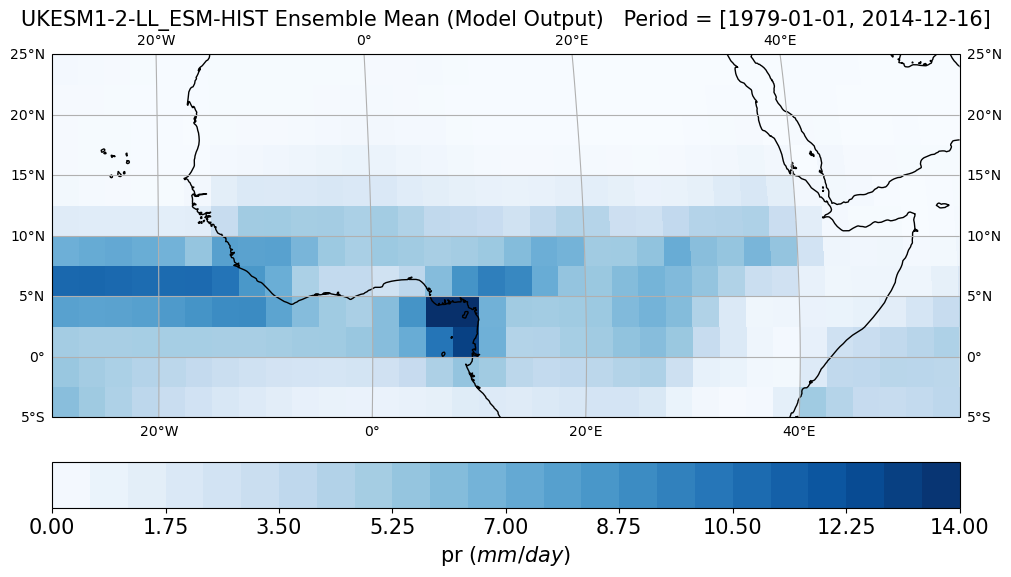

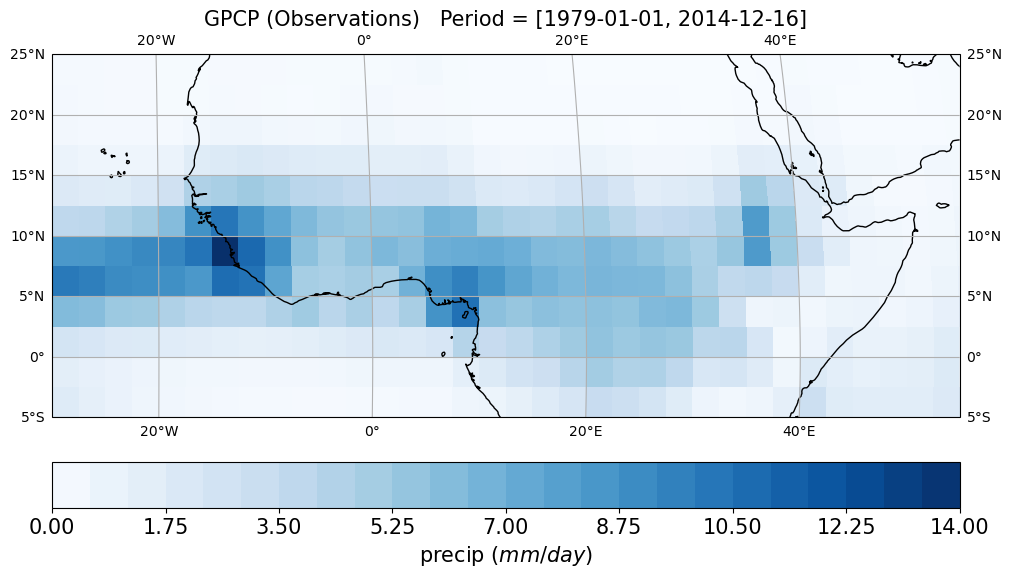

{'standard_deviation': 1.2445948123931885, 'min': -7.419381141662598, 'max': 18.28880500793457}


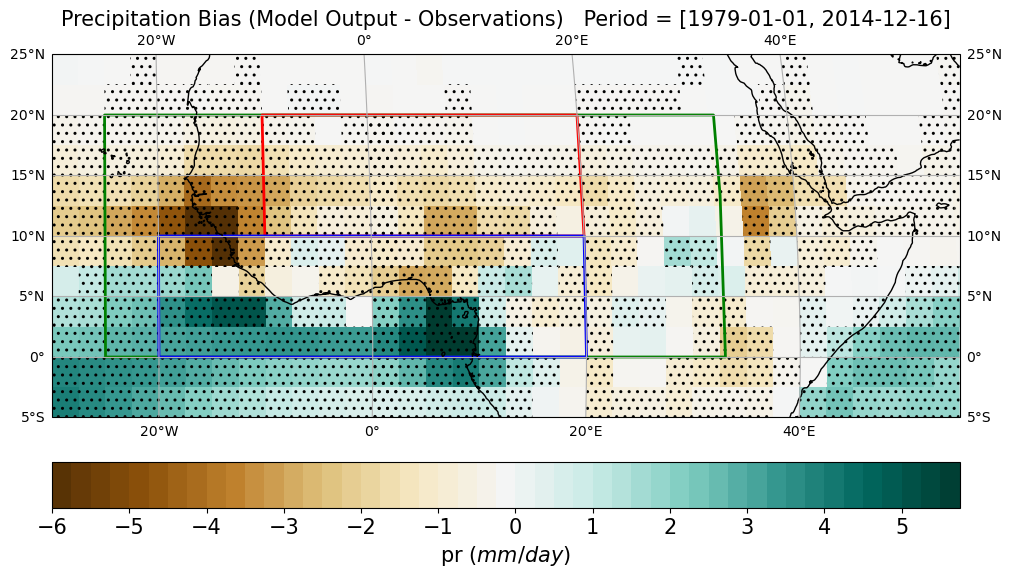

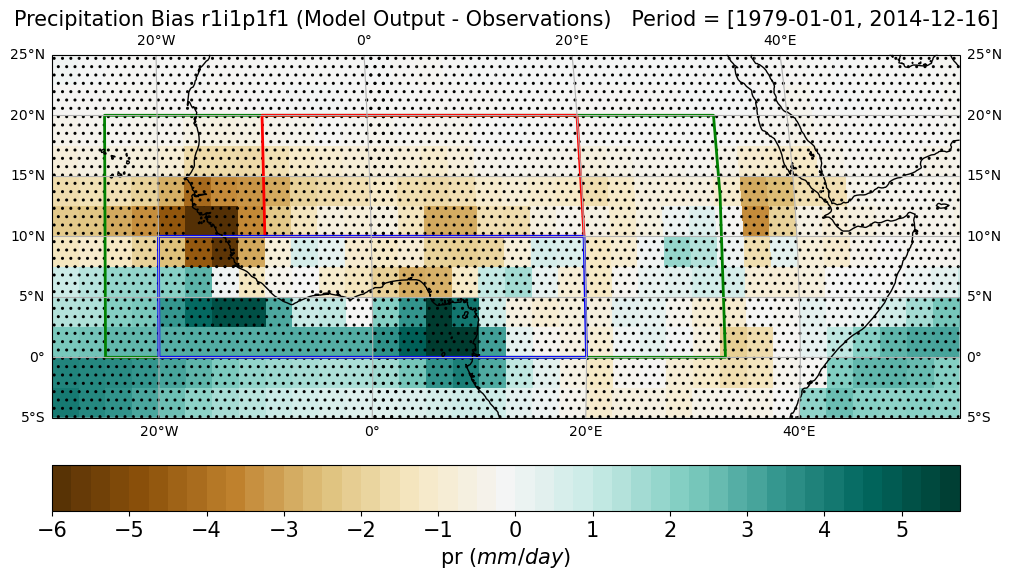

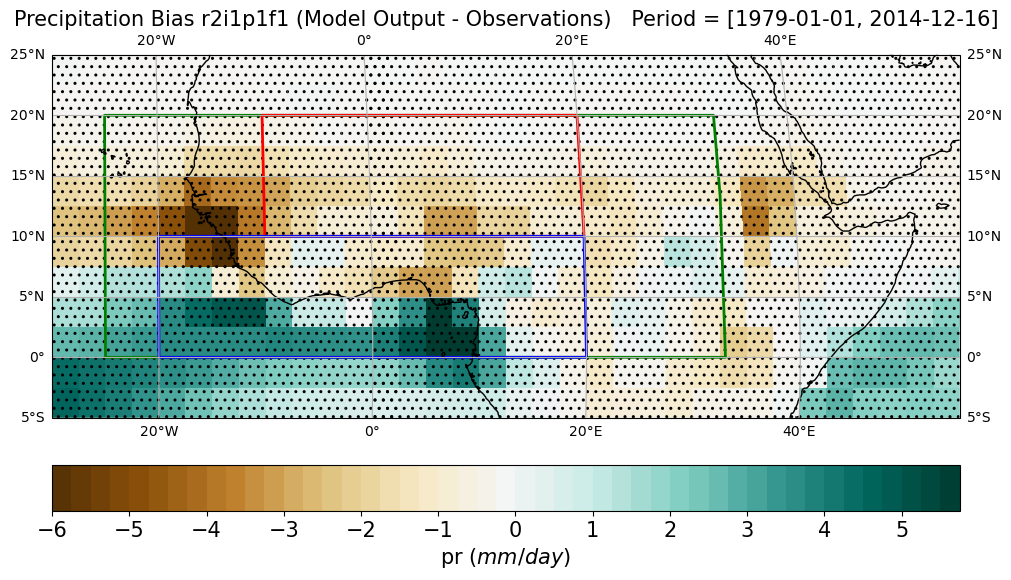

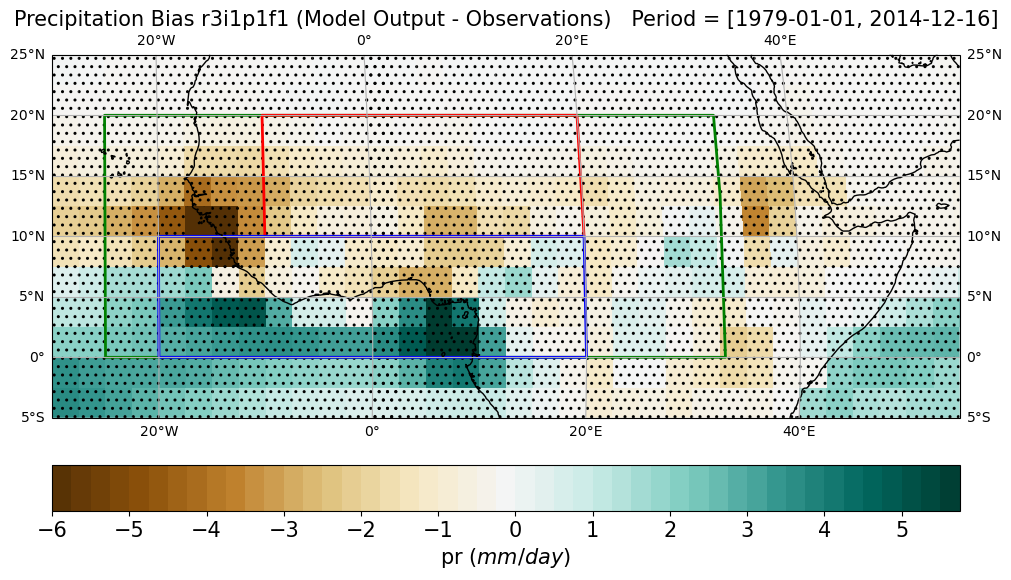

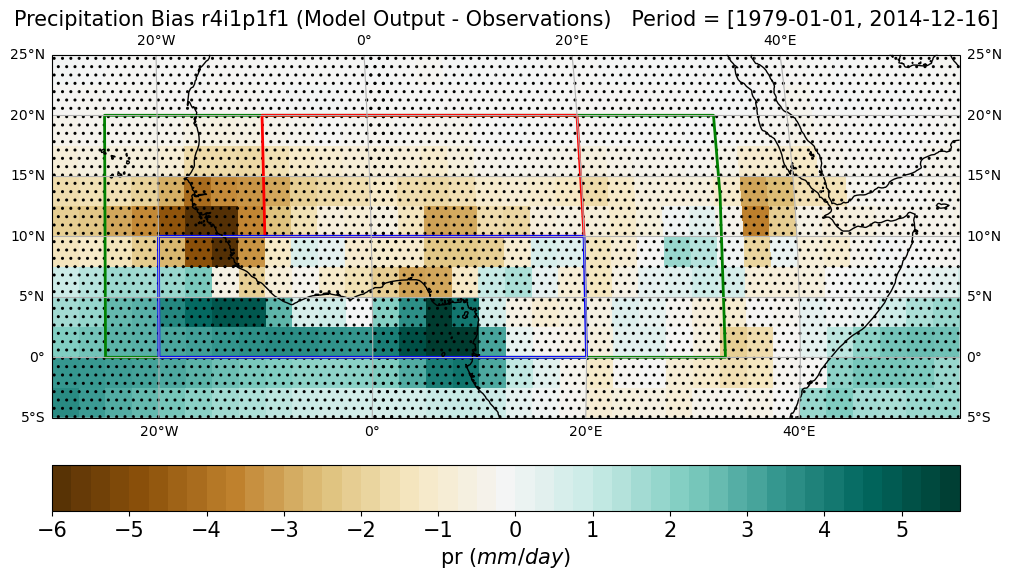

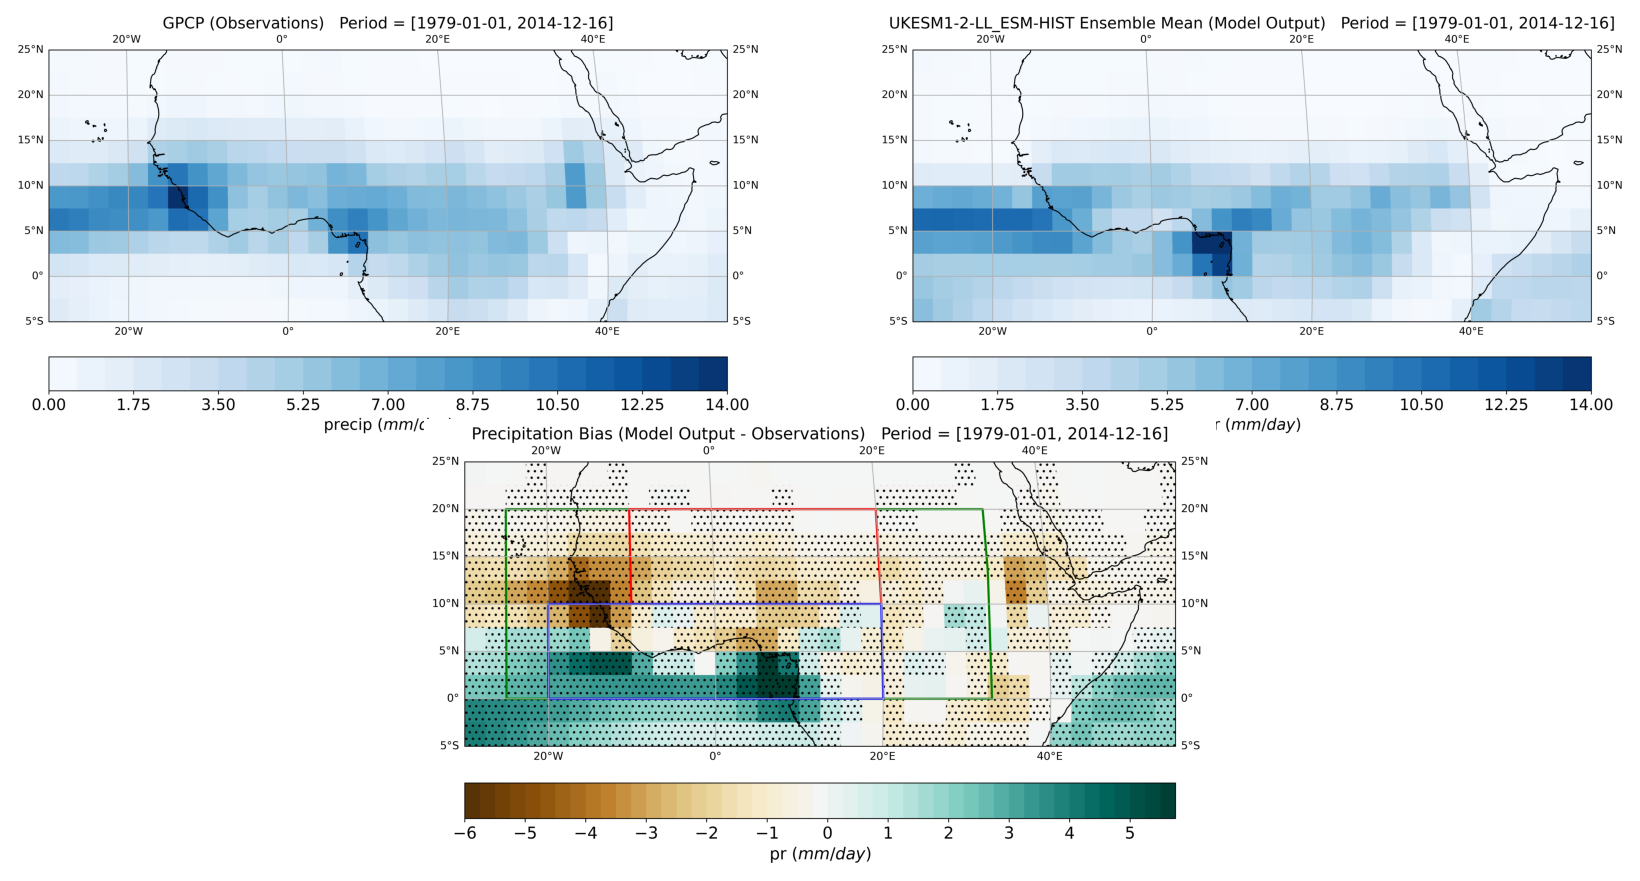

In [40]:
# Run precipitation Jupyter notebook.
# Located in the same directory as this notebook.
# Filename: precipitation_1
%run model_bias_analysis_precipitation_1_climatology_ts_hovmoller.ipynb

## Winds Observations Inset

### Load Interpolated Data

In [41]:
# Load interpolated observations.
filename = 'obs_interpolated.nc'
obs_path = f"/home/users/alvin_ch/files/Multi-model/UKESM/Winds/{filename}"
obs_file = xr.open_mfdataset(obs_path, combine='by_coords', use_cftime=True)
obs_file

<xarray.Dataset> Size: 86MB
Dimensions:         (valid_time: 1039, longitude: 144, bnds: 2, latitude: 72,
                     pressure_level: 1)
Coordinates:
  * valid_time      (valid_time) object 8kB 1940-01-01 00:00:00 ... 2026-07-0...
  * longitude       (longitude) float32 576B 1.25 3.75 6.25 ... 356.2 358.8
  * latitude        (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * pressure_level  (pressure_level) float64 8B 850.0
Dimensions without coordinates: bnds
Data variables:
    longitude_bnds  (longitude, bnds) float32 1kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    latitude_bnds   (latitude, bnds) float32 576B dask.array<chunksize=(72, 2), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 43MB dask.array<chunksize=(1, 1, 72, 144), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 43MB dask.array<chunksize=(1, 1, 72, 144), meta=np.ndarray>
Attributes:
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Aug 27 10:32:25 2026: cdo remapbil,/home/use...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

In [42]:
# Now we are interested in the same period as what we have in the observations.
# And that is 1979-2014.
filtered_obs = obs_file.sel(pressure_level=850).sel(valid_time=slice("1979-01-01", "2015-01-01"))

In [43]:
filtered_obs['u'].values[:1]

array([[[-3.3121529, -3.159809 , -3.0445747, ..., -3.9049263,
         -3.706684 , -3.4996529],
        [-2.985981 , -2.8717232, -2.7574654, ..., -3.5152779,
         -3.3512154, -3.1573677],
        [-3.6729927, -3.4640083, -3.145649 , ..., -4.303364 ,
         -4.1012154, -3.8614693],
        ...,
        [-2.6026802, -2.8839302, -3.0269966, ..., -1.8648872,
         -2.091938 , -2.3707466],
        [-3.7042427, -3.654438 , -3.598774 , ..., -3.7467232,
         -3.6866646, -3.6539497],
        [-4.194477 , -4.2110786, -4.2545357, ..., -4.3238716,
         -4.260395 , -4.212055 ]]], shape=(1, 72, 144), dtype=float32)

### Implementation 3a (Seasonal Mean)

In [44]:
# Similar function.
# Tweaked due to different variable names.
def seasonal_average_over_years_MJJAS_obs(data):

    # Select May-September
    data_mjjas = data.sel(valid_time=data.valid_time.dt.month.isin([5, 6, 7, 8, 9]))

    # Create annual MJJAS averages
    seasonal_avg = data_mjjas.groupby('valid_time.year').mean('valid_time')
    return seasonal_avg

In [45]:
seas = 'MJJAS'
seas_avg_obs = {}
obs_list = ['obs']

for expe in obs_list:
    obs_data = filtered_obs
    seas_avg_obs = seasonal_average_over_years_MJJAS_obs(obs_data)

In [46]:
seas_avg_obs['u'].values[:1]

array([[[-4.537744  , -4.46626   , -4.3893065 , ..., -4.9199705 ,
         -4.755713  , -4.628955  ],
        [-4.863721  , -4.7412596 , -4.570166  , ..., -5.707471  ,
         -5.384033  , -5.080713  ],
        [-6.885596  , -6.4781737 , -5.8646975 , ..., -7.924463  ,
         -7.4402833 , -7.0811033 ],
        ...,
        [-1.0088379 , -1.0490723 , -1.0197754 , ..., -0.8684082 ,
         -0.9072754 , -0.9590332 ],
        [-1.1568848 , -1.1527832 , -1.2533691 , ..., -1.0850098 ,
         -1.2113769 , -1.2266114 ],
        [-0.2652832 , -0.24985352, -0.27524415, ..., -0.48618165,
         -0.39946288, -0.31958008]]], shape=(1, 72, 144), dtype=float32)

## Surface Pressure Observations Inset

In [47]:
# Load interpolated observations.
filename = 'obs_psl_interpolated.nc'
obs_path = f"/home/users/alvin_ch/files/Multi-model/UKESM/Winds/{filename}"
obs_psl_file = xr.open_mfdataset(obs_path, combine='by_coords', use_cftime=True)
obs_psl_file

<xarray.Dataset> Size: 22MB
Dimensions:         (time: 528, bnds: 2, longitude: 144, latitude: 72)
Coordinates:
  * time            (time) object 4kB 1979-01-16 12:00:00 ... 2022-12-16 12:0...
  * longitude       (longitude) float32 576B 1.25 3.75 6.25 ... 356.2 358.8
  * latitude        (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds       (time, bnds) object 8kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    longitude_bnds  (longitude, bnds) float32 1kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    latitude_bnds   (latitude, bnds) float32 576B dask.array<chunksize=(72, 2), meta=np.ndarray>
    psl             (time, latitude, longitude) float32 22MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
Attributes: (12/43)
    CDI:                         Climate Data Interface version 2.5.0 (https:...
    Conventions:                 CF-1.11; ODS-2.5
    source:                      ECMWF-ERA-5 1.0 (2019): ECMWF - ERA5 (Europe...
    institution:                 The European Centre for Medium-Range Weather...
    CONVERSION_DATE:             Mon Nov 11 07:47:57 MST 2019
    CONVERSION_PLATFORM:         Linux casper02 3.10.0-693.21.1.el7.x86_64 #1...
    ...                          ...
    variable_id:                 psl
    variant_info:                obs4MIPs-compliant product prepared by PCMDI...
    variant_label:               PCMDI
    license:                     License to use Copernicus products available...
    cmor_version:                3.9.0
    CDO:                         Climate Data Operators version 2.5.0 (https:...

In [48]:
# Now we are interested in the same period as what we have in the observations.
# And that is 1979-2014.
filtered_obs_psl = obs_psl_file.sel(time=slice("1979-01-01", "2015-01-01"))
filtered_obs_psl

<xarray.Dataset> Size: 18MB
Dimensions:         (time: 432, bnds: 2, longitude: 144, latitude: 72)
Coordinates:
  * time            (time) object 3kB 1979-01-16 12:00:00 ... 2014-12-16 12:0...
  * longitude       (longitude) float32 576B 1.25 3.75 6.25 ... 356.2 358.8
  * latitude        (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds       (time, bnds) object 7kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    longitude_bnds  (longitude, bnds) float32 1kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    latitude_bnds   (latitude, bnds) float32 576B dask.array<chunksize=(72, 2), meta=np.ndarray>
    psl             (time, latitude, longitude) float32 18MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
Attributes: (12/43)
    CDI:                         Climate Data Interface version 2.5.0 (https:...
    Conventions:                 CF-1.11; ODS-2.5
    source:                      ECMWF-ERA-5 1.0 (2019): ECMWF - ERA5 (Europe...
    institution:                 The European Centre for Medium-Range Weather...
    CONVERSION_DATE:             Mon Nov 11 07:47:57 MST 2019
    CONVERSION_PLATFORM:         Linux casper02 3.10.0-693.21.1.el7.x86_64 #1...
    ...                          ...
    variable_id:                 psl
    variant_info:                obs4MIPs-compliant product prepared by PCMDI...
    variant_label:               PCMDI
    license:                     License to use Copernicus products available...
    cmor_version:                3.9.0
    CDO:                         Climate Data Operators version 2.5.0 (https:...

### Compute Seasonal Mean, Over Time

In [49]:
seas = 'MJJAS'
seas_avg_obs_psl = {}

data_psl = filtered_obs_psl
seas_avg_obs_psl['obs'] = seasonal_average_over_years_customed_MJJAS(data_psl)
seas_avg_obs_psl['obs'] /= 100

In [50]:
seas_avg_obs_psl

{'obs': <xarray.Dataset> Size: 2MB
 Dimensions:         (longitude: 144, latitude: 72, year: 35, bnds: 2)
 Coordinates:
   * longitude       (longitude) float32 576B 1.25 3.75 6.25 ... 356.2 358.8
   * latitude        (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
   * year            (year) int64 280B 1979 1980 1981 1982 ... 2011 2012 2013
 Dimensions without coordinates: bnds
 Data variables:
     longitude_bnds  (year, longitude, bnds) float32 40kB dask.array<chunksize=(1, 144, 2), meta=np.ndarray>
     latitude_bnds   (year, latitude, bnds) float32 20kB dask.array<chunksize=(1, 72, 2), meta=np.ndarray>
     psl             (year, latitude, longitude) float32 1MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>}

## Wind Bias Inset

### Compute Bias

In [51]:
# Compute bias for each component.
# Extract common years for fair comparison.
common_years = np.intersect1d(np.intersect1d(climatology_ens_mean_u['year'], climatology_ens_mean_v['year']),
                              seas_avg_obs['year'])

# Select common years only.
u_aligned = climatology_ens_mean_u.sel(year=common_years)
v_aligned = climatology_ens_mean_v.sel(year=common_years)
obs_u_aligned = seas_avg_obs['u'].sel(year=common_years)
obs_v_aligned = seas_avg_obs['v'].sel(year=common_years)

# Compute bias.
u_bias_compute = u_aligned - obs_u_aligned
v_bias_compute = v_aligned - obs_v_aligned

In [52]:
u_bias_compute.values[:1]

array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [1.8565308 , 1.8678589 , 1.811491  , ..., 1.828011  ,
         1.8243287 , 1.841752  ],
        [1.3890421 , 1.4038574 , 1.524406  , ..., 1.2546916 ,
         1.4022217 , 1.4391236 ],
        [0.22534181, 0.22714844, 0.27064618, ..., 0.39843345,
         0.32791746, 0.26334637]]], shape=(1, 72, 144), dtype=float32)

In [53]:
# Compute resultant bias vector.
resultant_bias = np.sqrt(u_bias_compute**2 + v_bias_compute**2)
resultant_bias.values[:1]

array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [1.8616111 , 1.8716912 , 1.8118496 , ..., 1.8726368 ,
         1.8471506 , 1.8566858 ],
        [1.3980498 , 1.4058475 , 1.5253259 , ..., 1.2651687 ,
         1.4234445 , 1.4631008 ],
        [0.22652149, 0.22886798, 0.27916262, ..., 0.40692297,
         0.34064603, 0.2719926 ]]], shape=(1, 72, 144), dtype=float32)

### Implementation 3a (Student t-Test)

In [54]:
def ttest_NO_bootstrap_bias(data_scen, data_piCTL):
    n_scen = data_scen.shape[0]
    n_ctl = data_piCTL.shape[0]

    # Make sure they have the same dimensions.
    if n_scen != n_ctl:
        raise TypeError('Sample sizes have different dimensions.')

    t_stat, p_value = ttest_ind(data_scen.values, data_piCTL.values, axis=0, equal_var=False)

    lat_name = [c for c in data_scen.coords if 'lat' in c.lower()][0]
    lon_name = [c for c in data_scen.coords if 'lon' in c.lower()][0]
    
    # Create an Xarray
    p_empirical_xr = xr.DataArray(
                p_value,
                dims=[lat_name, lon_name],
                coords={lat_name: data_scen[lat_name], lon_name: data_scen[lon_name]},
                name="p_value"
                )

    # Assign a name to your DataArray
    p_empirical_xr.name = "p_value"

    # Convert it to a Dataset (NetCDF requires a Dataset format)
    ds = p_empirical_xr.to_dataset()

    return ds

### Statistical Significance

In [55]:
import functools
import operator

# Bias per ensemble.
u_int_aligned_dict = {}
u_pvals_dict = {}
u_sig_masks = {}
u_bias = {}

v_int_aligned_dict = {}
v_pvals_dict = {}
v_sig_masks = {}

# Analyse per component.
### u-COMPONENT ###
for ens in ensemble_members:
    ds = time_filtered_ens_u[ens]
    
    # Extract model years
    model_years = ds['time'].dt.year

    # Compute seasonal mean per year for the model
    model_seas = ds['ua'].groupby(model_years).mean('time')
    model_seas = model_seas.rename({'year': 'year'})

    # Find common years
    common_years = np.intersect1d(seas_avg_obs['year'], model_seas['year'])

    # Align both datasets
    obs_aligned = seas_avg_obs.sel(year=common_years)
    u_int_aligned_dict[ens] = model_seas.sel(year=common_years)

    # Now t-test works because both have same shape
    u_pvals_dict[ens] = ttest_NO_bootstrap_bias(obs_aligned['u'], u_int_aligned_dict[ens])
    u_sig_masks[ens] = (u_pvals_dict[ens]['p_value'] < 0.05)

u_sig_all = functools.reduce(operator.and_, u_sig_masks.values())

lonmin = -20
lonmax = 55
latmin = -5
latmax = 25

u_sig_all_wam = u_sig_all.sel(longitude=slice(lonmin, lonmax),
                              latitude=slice(latmin, latmax))

n_sig_wam = int(u_sig_all_wam.sum())
n_total_wam = u_sig_all_wam.size
print('u-Components - Percentage of Significant Grid Cells in the Region')
print("\nNumber of Significant Cells (every ensemble) =", n_sig_wam)
print("Total number of cells =", n_total_wam)
print("Percentage of Grid Cells Significant in Every Ensemble =", 100 * n_sig_wam / n_total_wam)

u-Components - Percentage of Significant Grid Cells in the Region

Number of Significant Cells (every ensemble) = 230
Total number of cells = 264
Percentage of Grid Cells Significant in Every Ensemble = 87.12121212121212


In [56]:
for ens, ds in u_pvals_dict.items():
    p = ds['p_value']

    print(f"\n{ens}")
    print("min:", float(p.min()))
    print("max:", float(p.max()))
    print("mean:", float(p.mean()))
    print("median:", float(p.median()))
    print("p < 0.001:", int((p < 0.001).sum()))
    print("p < 0.01:", int((p < 0.01).sum()))
    print("p < 0.05:", int((p < 0.05).sum()))
    print("p < 0.10:", int((p < 0.10).sum()))


r1i1p1f1
min: 0.0
max: 0.998512864112854
mean: 0.08678697049617767
median: 1.3657381714438088e-06
p < 0.001: 6012
p < 0.01: 6707
p < 0.05: 7271
p < 0.10: 7539

r2i1p1f1
min: 0.0
max: 0.9996722340583801
mean: 0.08653437346220016
median: 7.813996489858255e-07
p < 0.001: 6180
p < 0.01: 6814
p < 0.05: 7336
p < 0.10: 7630

r3i1p1f1
min: 0.0
max: 0.9995294213294983
mean: 0.08645091205835342
median: 1.0636078968673246e-06
p < 0.001: 6100
p < 0.01: 6744
p < 0.05: 7292
p < 0.10: 7579

r4i1p1f1
min: 0.0
max: 0.9999537467956543
mean: 0.08456332236528397
median: 1.0448007969898754e-06
p < 0.001: 6093
p < 0.01: 6788
p < 0.05: 7306
p < 0.10: 7604


In [57]:
for ens in ensemble_members:
    bias = (u_int_aligned_dict[ens] - seas_avg_obs.sel(year=u_int_aligned_dict[ens]['year'])['u'])

    print(ens,
        "bias mean =", float(bias.mean()),
        "bias std =", float(bias.std()),
        "bias min =", float(bias.min()),
        "bias max =", float(bias.max()))

r1i1p1f1 bias mean = -0.3077397346496582 bias std = 2.2255091667175293 bias min = -14.928882598876953 bias max = 12.053201675415039
r2i1p1f1 bias mean = -0.3106078803539276 bias std = 2.254074811935425 bias min = -16.011198043823242 bias max = 10.027054786682129
r3i1p1f1 bias mean = -0.318815141916275 bias std = 2.2545924186706543 bias min = -14.871357917785645 bias max = 10.463926315307617
r4i1p1f1 bias mean = -0.30329254269599915 bias std = 2.2436141967773438 bias min = -15.388595581054688 bias max = 10.024148941040039


In [58]:
### v-COMPONENT ###
for ens in ensemble_members:
    ds = time_filtered_ens_v[ens]
    
    # Extract model years
    model_years = ds['time'].dt.year

    # Compute seasonal mean per year for the model
    model_seas = ds['va'].groupby(model_years).mean('time')
    model_seas = model_seas.rename({'year': 'year'})

    # Find common years
    common_years = np.intersect1d(seas_avg_obs['year'], model_seas['year'])

    # Align both datasets
    obs_aligned = seas_avg_obs.sel(year=common_years)
    v_int_aligned_dict[ens] = model_seas.sel(year=common_years)

    # Now t-test works because both have same shape
    v_pvals_dict[ens] = ttest_NO_bootstrap_bias(obs_aligned['v'], v_int_aligned_dict[ens])
    v_sig_masks[ens] = (v_pvals_dict[ens]['p_value'] < 0.05)

v_sig_all = functools.reduce(operator.and_, v_sig_masks.values())

lonmin = -20
lonmax = 55
latmin = -5
latmax = 25

v_sig_all_wam = v_sig_all.sel(longitude=slice(lonmin, lonmax),
                              latitude=slice(latmin, latmax))

n_sig_wam = int(v_sig_all_wam.sum())
n_total_wam = v_sig_all_wam.size
print('v-Components - Percentage of Significant Grid Cells in the Region')
print("\nNumber of Significant Cells (every ensemble) =", n_sig_wam)
print("Total number of cells =", n_total_wam)
print("Percentage of Grid Cells Significant in Every Ensemble =", 100 * n_sig_wam / n_total_wam)

v-Components - Percentage of Significant Grid Cells in the Region

Number of Significant Cells (every ensemble) = 224
Total number of cells = 264
Percentage of Grid Cells Significant in Every Ensemble = 84.84848484848484


### Implementation 3b (Climatology with Precipitation Shading)

In [59]:
def bias_quiver_pr_shading(u_wind_bias, v_wind_bias, shading_bias_data, cbar_label, palette,
                           lonmin, lonmax, latmin, latmax, title, Save, filename, p_values):
    
    fig = plt.figure(figsize=(10,10), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=-30))

    ### SHADING BIAS ###
    lat_name = list(shading_bias_data.coords)[1]
    lon_name = list(shading_bias_data.coords)[0]
    
    # Extract original lat/lon
    lon_orig = shading_bias_data.coords[lon_name].values
    lat = shading_bias_data.coords[lat_name].values

    # Add cyclic point to data
    data_cyclic, lon_cyclic = add_cyclic_point(shading_bias_data.values, coord=lon_orig, axis=1)

    # Create 2D grids
    lon2d, lat2d = np.meshgrid(lon_cyclic, lat)
    
    # Plot the filled contours
    levels = np.linspace(-6, 6, 25)
    contour = ax.contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=palette)

    vmin = -6
    vmax = 6
    
    mm = ax.pcolormesh(lon2d, lat2d, data_cyclic,
                       vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(),
                       cmap=palette)
    
    # Add hatching for significant p-values
    if p_values is not None:
        
        # Add cyclic point to p_values using the original lon (not lon_cyclic)
        p_cyclic, _ = add_cyclic_point(p_values.values, coord=lon_orig, axis=1)

        # Compute mask
        sig_mask = p_cyclic <= 0.05
        hatch_mask = np.where(sig_mask, 1, np.nan)

        # Overlay hatching
        ax.pcolor(lon2d, lat2d, hatch_mask,
                  hatch='..',
                  alpha=0.0,
                  transform=ccrs.PlateCarree(),
                  zorder=1)

    ### WIND VECTOR QUIVERS ###
    u = u_wind_bias
    v = v_wind_bias

    # Resultant speed - coloured arrows only.
    s = np.sqrt(u**2 + v**2)

    # Subsample to avoid too many arrows.
    step = 2
    
    u = u.values[::step, ::step]
    v = v.values[::step, ::step]
    s = s.values[::step, ::step]

    # Reinitialise axes.
    lats = u_wind_bias['latitude'].values
    lons = v_wind_bias['longitude'].values
    lon2d, lat2d = np.meshgrid(lons, lats)
    
    x = lon2d[::step, ::step]
    y = lat2d[::step, ::step]

    # Plot arrows
    arrows = plt.quiver(x, y, u, v, color='navy', scale=45, pivot='middle', transform=ccrs.PlateCarree())

    # Scale arrow
    plt.quiverkey(arrows, X=0.895, Y=1.03, U=1, label='1 m/s', labelpos='E', coordinates='axes')
    
    # Set the map's extent (to zoom into the North Atlantic region)
    ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.coastlines()
    ax.gridlines(draw_labels=True)
        
    # Colorbar
    cbar = plt.colorbar(contour, orientation='horizontal', drawedges=False, extend='both', pad=0.05)
    cbar.ax.tick_params(labelsize=15) 
    cbar.set_label(label=cbar_label, fontsize=15)

    # Title
    plt.title(title, fontsize=15)

    # Save if requested
    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)

    plt.show()

## Surface Pressure Bias Inset

### Compute Bias

In [60]:
# Compute bias for each component.
# Extract common years for fair comparison.
common_years = np.intersect1d(climatology_ens_mean_psl['year'], seas_avg_obs_psl['obs']['year'])

# Select common years only.
psl_ens_aligned = climatology_ens_mean_psl.sel(year=common_years)
psl_obs_aligned = seas_avg_obs_psl['obs'].sel(year=common_years)

# Compute bias.
psl_bias = psl_ens_aligned - psl_obs_aligned
psl_bias

<xarray.Dataset> Size: 7MB
Dimensions:         (longitude: 144, latitude: 72, year: 35, bnds: 2)
Coordinates:
  * longitude       (longitude) float32 576B 1.25 3.75 6.25 ... 356.2 358.8
  * latitude        (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * year            (year) int64 280B 1979 1980 1981 1982 ... 2011 2012 2013
Dimensions without coordinates: bnds
Data variables:
    longitude_bnds  (year, latitude, longitude, bnds) float32 3MB dask.array<chunksize=(1, 72, 144, 2), meta=np.ndarray>
    latitude_bnds   (year, latitude, longitude, bnds) float32 3MB dask.array<chunksize=(1, 72, 144, 2), meta=np.ndarray>
    psl             (year, latitude, longitude) float32 1MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>

### Statistical Significance

In [61]:
# Bias per ensemble.
psl_int_aligned_dict = {}
psl_pvals_dict = {}
psl_sig_masks = {}

# Surface Level Pressure
for ens in ensemble_members:
    if ens == 'r4i1p1f1':
        continue
    else:
        ds = time_filtered_ens_psl[ens] / 100
        
        # Extract model years
        model_years = ds['time'].dt.year
    
        # Compute seasonal mean per year for the model
        model_seas = ds['psl'].groupby(model_years).mean('time')
        model_seas = model_seas.rename({'year': 'year'})
    
        # Find common years
        common_years = np.intersect1d(seas_avg_obs_psl['obs']['year'], model_seas['year'])
    
        # Align both datasets
        obs_aligned = seas_avg_obs_psl['obs']['psl'].sel(year=common_years)
        model_aligned = model_seas.sel(year=common_years)
    
        psl_int_aligned_dict[ens] = model_aligned
    
        # T-test
        psl_pvals_dict[ens] = ttest_NO_bootstrap_bias(obs_aligned, model_aligned)
    
        # Significant cells
        psl_sig_masks[ens] = (psl_pvals_dict[ens]['p_value'] < 0.05)

In [62]:
# Cells significant in EVERY ensemble member
psl_sig_all = functools.reduce(operator.and_, psl_sig_masks.values())
n_sig_all = int(psl_sig_all.sum())

# Total number of grid cells
n_total = psl_pvals_dict[ensemble_members[0]]['p_value'].size
pct_sig_all = 100 * n_sig_all / n_total

print('PSL - Percentage of Significant Grid Cells')

for ens, ds in psl_pvals_dict.items():
    da = ds['p_value']

    sig = da < 0.05

    n_sig = int(sig.sum())
    pct = 100 * n_sig / sig.size

    print(f"{ens}: {n_sig} significant ({pct:.2f}%)")

print('\nNumber of Significant Cells (every ensemble) =', n_sig_all)
print('Total number of cells =', n_total)
print('Percentage of Grid Cells Significant in Every Ensemble =', pct_sig_all)

PSL - Percentage of Significant Grid Cells
r1i1p1f1: 8734 significant (84.24%)
r2i1p1f1: 8829 significant (85.16%)
r3i1p1f1: 8780 significant (84.68%)

Number of Significant Cells (every ensemble) = 8461
Total number of cells = 10368
Percentage of Grid Cells Significant in Every Ensemble = 81.60686728395062


### Implementation 4a (Climatology with Surface Pressure Shading)

In [63]:
def bias_quiver_psl_shading(u_wind_bias, v_wind_bias, shading_bias_data, cbar_label, palette,
                            lonmin, lonmax, latmin, latmax, title, Save, filename, p_values):
    
    fig = plt.figure(figsize=(10,10), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=-30))

    ### SHADING BIAS ###
    lat_name = list(shading_bias_data.coords)[1]
    lon_name = list(shading_bias_data.coords)[0]
    
    # Extract original lat/lon
    lon_orig = shading_bias_data.coords[lon_name].values
    lat = shading_bias_data.coords[lat_name].values

    # Add cyclic point to data
    data_cyclic, lon_cyclic = add_cyclic_point(shading_bias_data.values, coord=lon_orig, axis=1)

    # Create 2D grids
    lon2d, lat2d = np.meshgrid(lon_cyclic, lat)
    
    # Plot the filled contours
    levels = np.linspace(-3.5, 3.5, 25)
    contour = ax.contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=palette)

    vmin = -3.5
    vmax = 3.5
    
    mm = ax.pcolormesh(lon2d, lat2d, data_cyclic,
                       vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(),
                       cmap=palette)
    
    # Add hatching for significant p-values
    if p_values is not None:
        
        # Add cyclic point to p_values using the original lon (not lon_cyclic)
        p_cyclic, _ = add_cyclic_point(p_values.values, coord=lon_orig, axis=1)

        # Compute mask
        sig_mask = p_cyclic <= 0.05
        hatch_mask = np.where(sig_mask, 1, np.nan)

        # Overlay hatching
        ax.pcolor(lon2d, lat2d, hatch_mask,
                  hatch='..',
                  alpha=0.0,
                  transform=ccrs.PlateCarree(),
                  zorder=1)

    ### WIND VECTOR QUIVERS ###
    u = u_wind_bias
    v = v_wind_bias

    # Resultant speed - coloured arrows only.
    s = np.sqrt(u**2 + v**2)

    # Subsample to avoid too many arrows.
    step = 2
    
    u = u.values[::step, ::step]
    v = v.values[::step, ::step]
    s = s.values[::step, ::step]

    # Reinitialise axes.
    lats = u_wind_bias['latitude'].values
    lons = v_wind_bias['longitude'].values
    lon2d, lat2d = np.meshgrid(lons, lats)
    
    x = lon2d[::step, ::step]
    y = lat2d[::step, ::step]

    # Plot arrows
    arrows = plt.quiver(x, y, u, v, color='navy', scale=45, pivot='middle', transform=ccrs.PlateCarree())

    # Scale arrow
    plt.quiverkey(arrows, X=0.895, Y=1.03, U=1, label='1 m/s', labelpos='E', coordinates='axes')
    
    # Set the map's extent (to zoom into the North Atlantic region)
    ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.coastlines()
    ax.gridlines(draw_labels=True)
        
    # Colorbar
    cbar = plt.colorbar(contour, orientation='horizontal', drawedges=False, extend='both', pad=0.05)
    cbar.ax.tick_params(labelsize=15) 
    cbar.set_label(label=cbar_label, fontsize=15)

    # Title
    plt.title(title, fontsize=15)

    # Save if requested
    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)

    plt.show()

## Seasonal Climatology Map

### Model Map

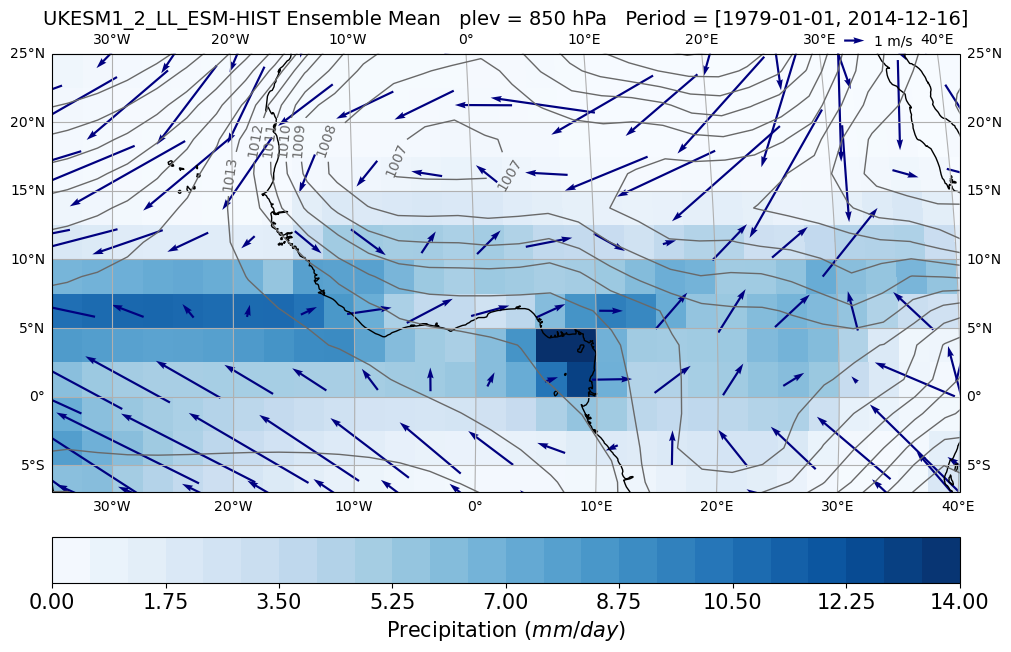

In [64]:
# Shading map with precipitation data and apply the above implementation.
# Now we can run code with variables recalled in the precipitation notebook.

# Reinitialise file paths.
path_figure = f"/home/users/alvin_ch/figures/Multi-model/{model_short}/Winds/"
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Winds/"

# Mapping extent.
lonmin = -35
lonmax = 40
latmin = -7
latmax = 25

# Function parameters.
unit = 'mm/day'
vmin = 0
vmax = 14
palette = plt.cm.Blues
reg = 'WAM'
seas = 'MJJAS'
var = 'Precipitation'

cbar_label = var+' ($'+unit+'$)'
title = 'UKESM1_2_LL_ESM-HIST Ensemble Mean   plev = 850 hPa   Period = [1979-01-01, 2014-12-16]'
Save = True
filename = f'{path_figure}/''WAM_Map-winds_UKESM1-2-LL_ESM-HIST_Ensemble_Mean'+seas+'.png'

# Plot
quiver_pr_map_WAM(climatology_map_data, climatology_ens_mean_u, climatology_ens_mean_v, climatology_ens_mean_psl,
                  vmin, vmax, cbar_label, palette, lonmin, lonmax, latmin, latmax, title, Save, filename)

### Observations Map

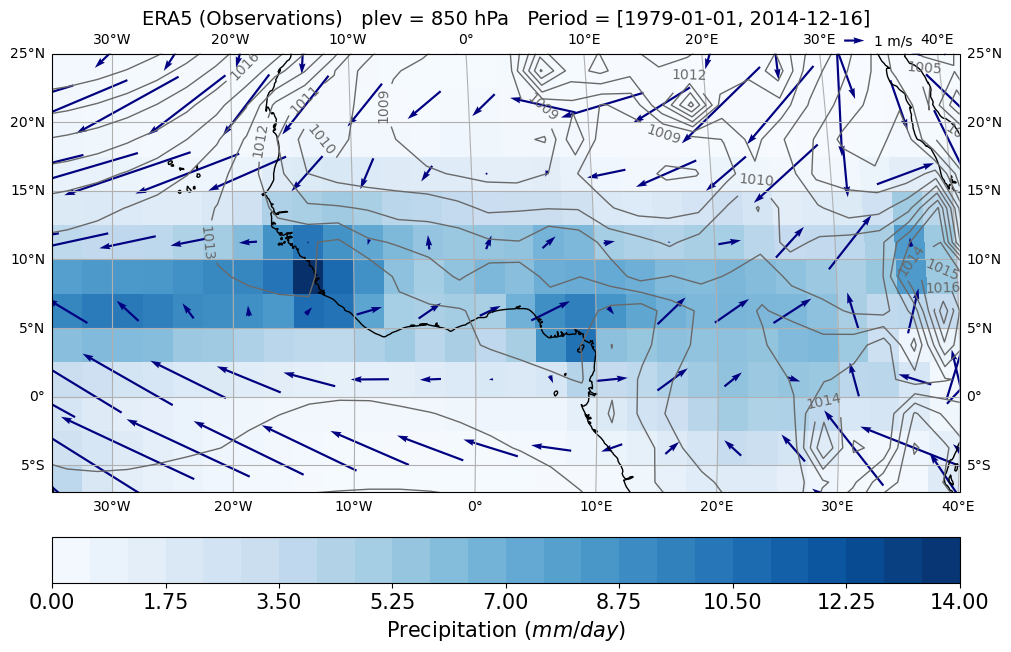

In [65]:
# Mapping extent.
lonmin = -35
lonmax = 40
latmin = -7
latmax = 25

# Function parameters.
unit = 'mm/day'
vmin = 0
vmax = 14
palette = plt.cm.Blues
reg = 'WAM'
seas = 'MJJAS'
var = 'Precipitation'

cbar_label = var+' ($'+unit+'$)'
title = 'ERA5 (Observations)   plev = 850 hPa   Period = [1979-01-01, 2014-12-16]'
Save = True 
filename = f'{path_figure}/''WAM_Map-winds_ERA5'+seas+'.png'

# Plot
quiver_pr_map_WAM(obs_map_data, seas_avg_obs['u'], seas_avg_obs['v'], seas_avg_obs_psl['obs']['psl'],
                  vmin, vmax, cbar_label, palette, lonmin, lonmax, latmin, latmax, title, Save, filename)

### Bias Map 1 (Precipitation Bias Shading)

In [66]:
# Check precipitation bias data.
bias_data

<xarray.DataArray (latitude: 72, longitude: 144)> Size: 41kB
dask.array<mean_agg-aggregate, shape=(72, 144), dtype=float32, chunksize=(72, 144), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75

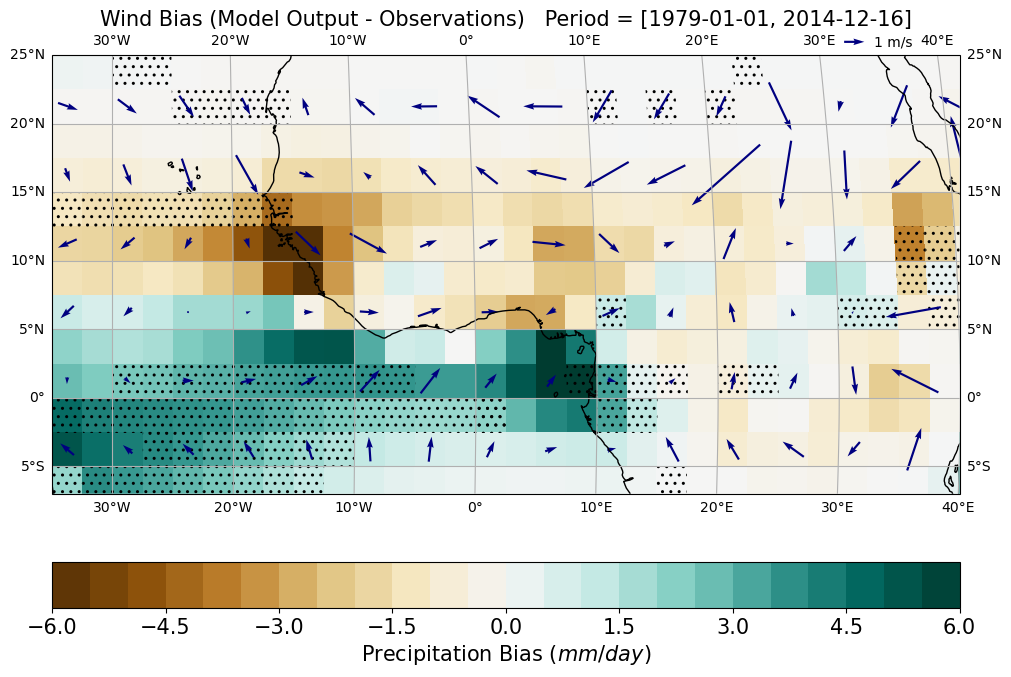

In [67]:
# Plot parameters
lonmin = -35
lonmax = 40
latmin = -7
latmax = 25

# Function parameters
unit = 'mm/day'
palette = plt.cm.BrBG
reg = 'WAM'
seas = 'MJJAS'
bar_var = 'Precipitation Bias'

# Data ready for plot.
u_bias_data = u_bias_compute.mean(dim='year')
v_bias_data = v_bias_compute.mean(dim='year')

# Remaining Formatting
cbar_label = bar_var+' ($'+unit+'$)'
title = f'Wind Bias (Model Output - Observations)   Period = [1979-01-01, 2014-12-16]'
Save = True 
filename = f'{path_figure}/''WAM_Map-Winds_'+'Bias_'+seas+'_with_Precip_Shading.png'

# Plot
# Here bias_data is the precipitation bias.
bias_quiver_pr_shading(u_bias_data, v_bias_data, bias_data, cbar_label, palette,
                       lonmin, lonmax, latmin, latmax, title, Save, filename, u_sig_all)

### Bias Map 2 (Precipitation Bias Shading)

In [68]:
bias_data

<xarray.DataArray (latitude: 72, longitude: 144)> Size: 41kB
dask.array<mean_agg-aggregate, shape=(72, 144), dtype=float32, chunksize=(72, 144), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75

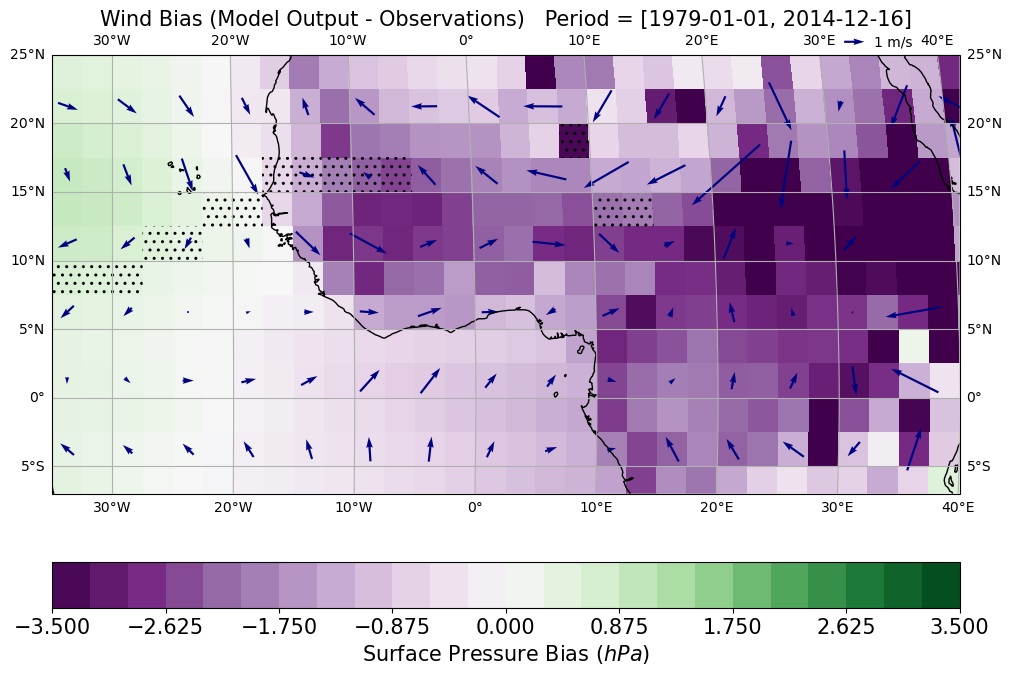

In [69]:
# Plot parameters
lonmin = -35
lonmax = 40
latmin = -7
latmax = 25

# Function parameters
unit = 'hPa'
palette = plt.cm.PRGn
reg = 'WAM'
seas = 'MJJAS'
bar_var = 'Surface Pressure Bias'

# Data ready for plot.
u_bias_data = u_bias_compute.mean(dim='year')
v_bias_data = v_bias_compute.mean(dim='year')
psl_bias_data = psl_bias.mean(dim='year')

# Remaining Formatting
cbar_label = bar_var+' ($'+unit+'$)'
title = f'Wind Bias (Model Output - Observations)   Period = [1979-01-01, 2014-12-16]'
Save = True 
filename = f'{path_figure}/''WAM_Map-Winds_'+'Bias_'+seas+'_with_psl_Shading.png'

# Plot
# Here bias_data is the precipitation bias.
bias_quiver_psl_shading(u_bias_data, v_bias_data, psl_bias_data['psl'], cbar_label, palette,
                        lonmin, lonmax, latmin, latmax, title, Save, filename, psl_sig_all)

### Final Figure

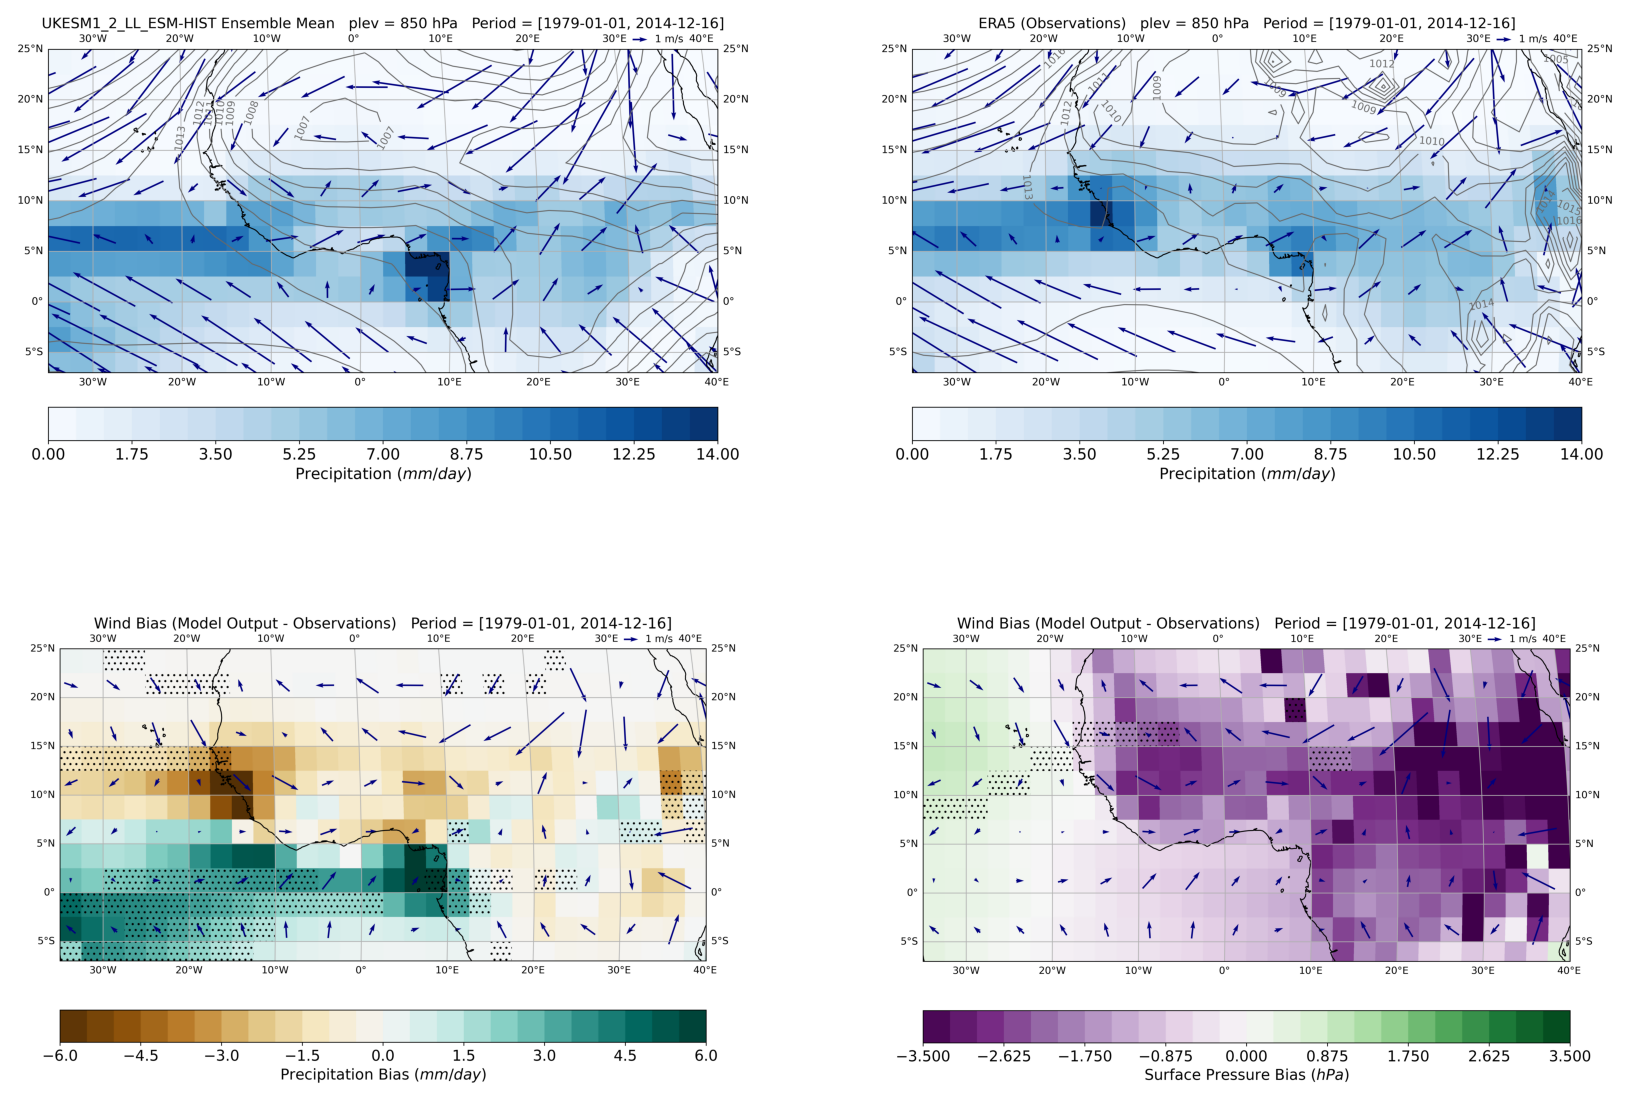

In [70]:
import matplotlib.image as mpimg

fig = plt.figure(figsize=(18, 12))

ax1 = fig.add_axes([0.05, 0.55, 0.42, 0.40])   # [left, bottom, width, height]
ax1.imshow(mpimg.imread(f"{path_figure}WAM_Map-winds_UKESM1-2-LL_ESM-HIST_Ensemble_MeanMJJAS.png"))
ax1.axis("off")

ax2 = fig.add_axes([0.53, 0.55, 0.42, 0.40])
ax2.imshow(mpimg.imread(f"{path_figure}WAM_Map-winds_ERA5MJJAS.png"))
ax2.axis("off")

ax3 = fig.add_axes([0.05, 0.05, 0.42, 0.40])
ax3.imshow(mpimg.imread(f"{path_figure}WAM_Map-Winds_Bias_MJJAS_with_Precip_Shading.png"))
ax3.axis("off")

ax4 = fig.add_axes([0.53, 0.05, 0.42, 0.40])
ax4.imshow(mpimg.imread(f"{path_figure}WAM_Map-Winds_Bias_MJJAS_with_psl_Shading.png"))
ax4.axis("off")

plt.savefig(f"{path_figure}WAM_Map-Winds_Climatology.png", bbox_inches='tight', pad_inches=0.1, dpi=450)
plt.show()